# Importing Libararies

In [1]:
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px
import time

from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, classification_report, precision_score, recall_score, f1_score , fbeta_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("✅ Libraries imported successfully!")

import warnings
warnings.filterwarnings("ignore")

✅ Libraries imported successfully!


In [2]:
# Load & Read The Data 
df = pd.read_csv('census.csv')
df.head()

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


# Data Exploration

In [3]:
print("Dataset Dimensions:", df.shape)
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Dataset Dimensions: (45222, 14)
Number of Rows: 45222
Number of Columns: 14


In [4]:
cols = df.columns.tolist()
print("Columns Names:", cols)

Columns Names: ['age', 'workclass', 'education_level', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


In [5]:
# Data Info (Data Type of Each column)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              45222 non-null  int64  
 1   workclass        45222 non-null  object 
 2   education_level  45222 non-null  object 
 3   education-num    45222 non-null  float64
 4   marital-status   45222 non-null  object 
 5   occupation       45222 non-null  object 
 6   relationship     45222 non-null  object 
 7   race             45222 non-null  object 
 8   sex              45222 non-null  object 
 9   capital-gain     45222 non-null  float64
 10  capital-loss     45222 non-null  float64
 11  hours-per-week   45222 non-null  float64
 12  native-country   45222 non-null  object 
 13  income           45222 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 4.8+ MB


In [6]:
# Statistical Summary 
df.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,10.118460,1101.430344,88.595418,40.938017
std,13.217870,2.552881,7506.430084,404.956092,12.007508
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


**Notes on numerical columns:**
1. capital-gain&capital-loss: Skewed Distribution.
2. capital-gain max = 99999 --> Outlier

In [7]:
df.describe(include='O')

,workclass,education_level,marital-status,occupation,relationship,race,sex,native-country,income
count,45222,45222,45222,45222,45222,45222,45222,45222,45222
unique,7,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,United-States,<=50K
freq,33307,14783,21055,6020,18666,38903,30527,41292,34014


**Observations**
1. Income Distribution is Imbalanced (it has 34014 for <=50k in income).
2. Native Country Has High Cardinality (it has 41 unique countries).
3. Binary Categorical Features (e.g., sex, income).

In [8]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

In [9]:
# Categorical Features Values
for col in categorical_cols:
    print(df[col].value_counts())
    print('===========')

workclass
Private             33307
Self-emp-not-inc     3796
Local-gov            3100
State-gov            1946
Self-emp-inc         1646
Federal-gov          1406
Without-pay            21
Name: count, dtype: int64
education_level
HS-grad         14783
Some-college     9899
Bachelors        7570
Masters          2514
Assoc-voc        1959
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           823
Prof-school       785
9th               676
12th              577
Doctorate         544
5th-6th           449
1st-4th           222
Preschool          72
Name: count, dtype: int64
marital-status
Married-civ-spouse       21055
Never-married            14598
Divorced                  6297
Separated                 1411
Widowed                   1277
Married-spouse-absent      552
Married-AF-spouse           32
Name: count, dtype: int64
occupation
Craft-repair         6020
Prof-specialty       6008
Exec-managerial      5984
Adm-clerical         5540
Sales          

In [10]:
# #import os
# #from ydata_profiling import ProfileReport

# #os.makedirs("reports", exist_ok=True)

# #profile = ProfileReport(df, title="Pandas Profiling Report")
# #profile.to_file("reports/first-exploration.html")

# #profile.to_notebook_iframe()

# from pandas_profiling import ProfileReport

# pr_rep = ProfileReport(df, title="Pandas Profiling Report")
# pr_rep

In [11]:
d = df["income"].value_counts()
target = pd.DataFrame(d)
target

,count
income,
<=50K,34014
>50K,11208


In [12]:
num_above_50k = d['>50K']
num_below_eq_50k = d['<=50K']

print("Number of individuals with income >$50,000:", num_above_50k)
print("Number of individuals with income <=$50,000:", num_below_eq_50k)

Number of individuals with income >$50,000: 11208
Number of individuals with income <=$50,000: 34014


In [13]:
perc_above_50k = (num_above_50k/df.shape[0]) * 100
print("Percentage of individuals with income >$50,000: {:.2f}%".format(perc_above_50k))

Percentage of individuals with income >$50,000: 24.78%


# Visualizations

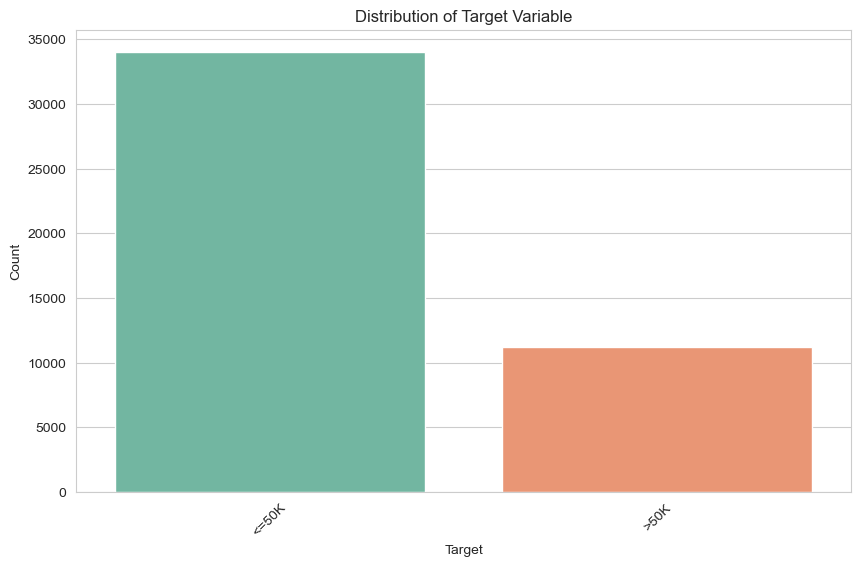

In [14]:
#colors = ['#FF9999','#66B3FF','#99FF99','#FFCC99','#C2C2F0','#FFB266']

sns.countplot(x='income', data=df, palette='Set2')
plt.title('Distribution of Target Variable')
plt.xlabel('Target')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

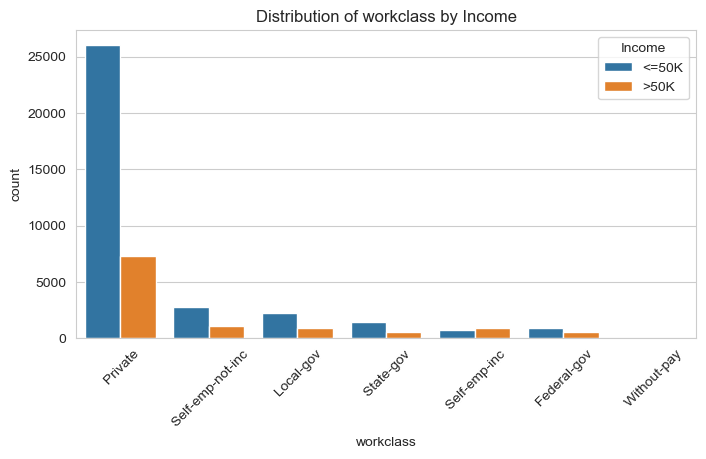

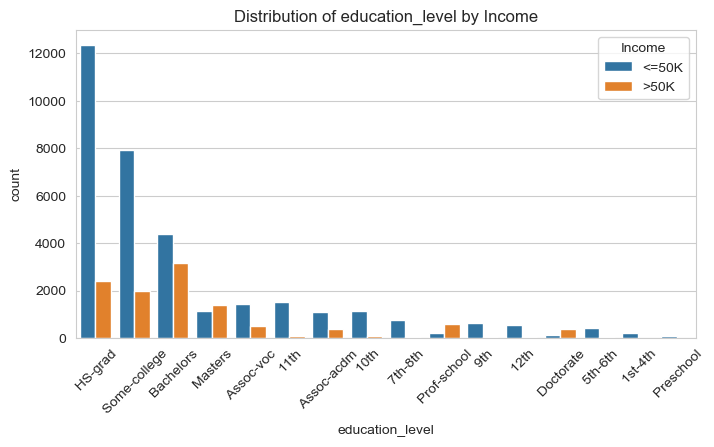

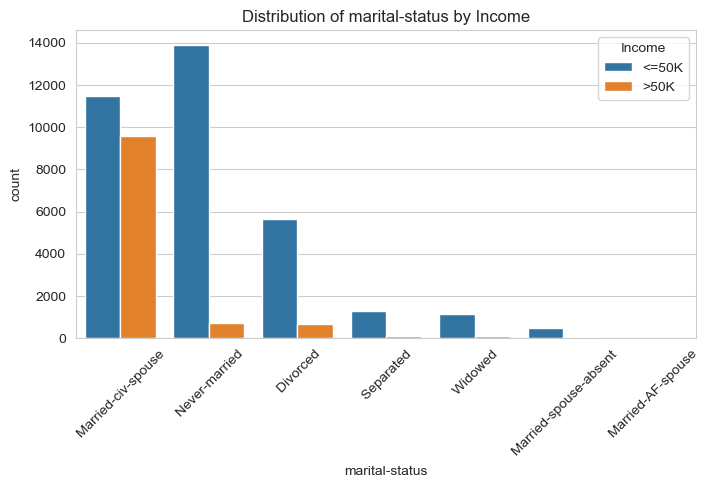

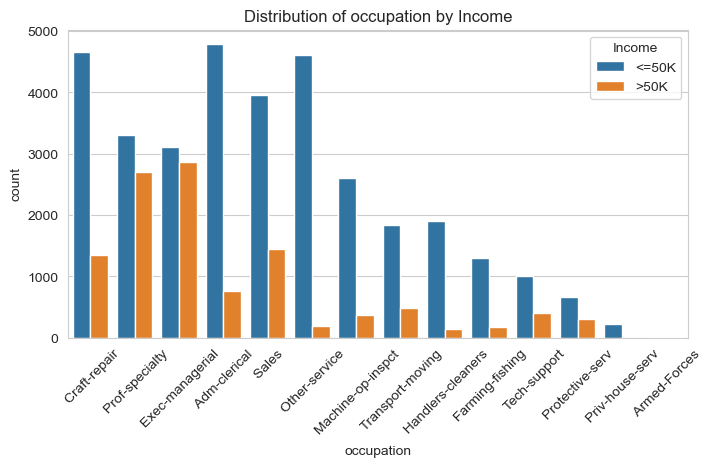

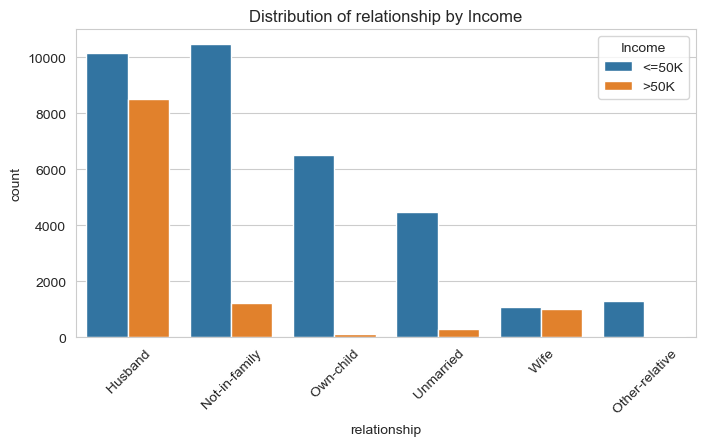

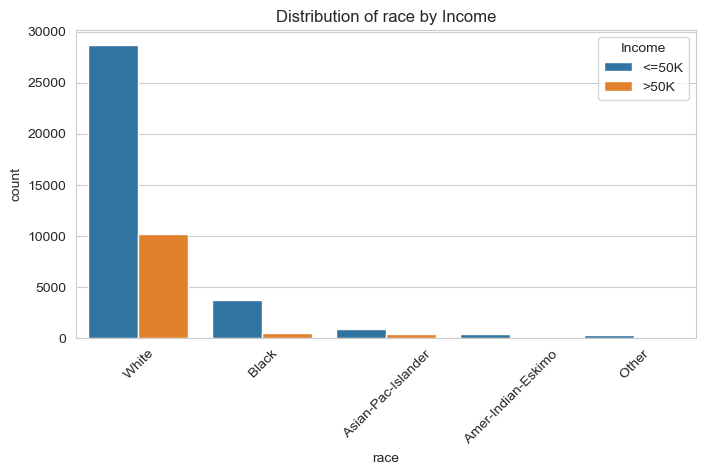

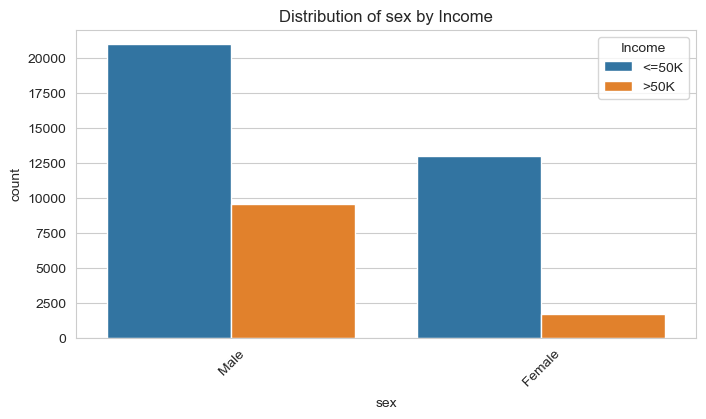

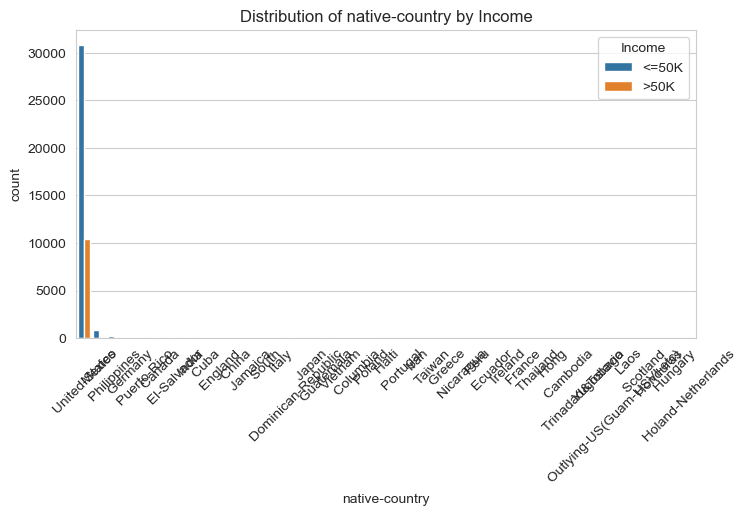

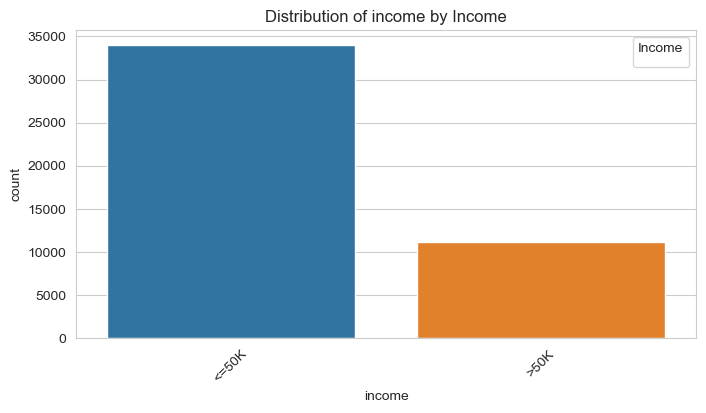

In [15]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df, hue='income', order=df[col].value_counts().index)
    plt.title(f'Distribution of {col} by Income')
    plt.xticks(rotation=45)
    plt.legend(title='Income')
    plt.show()

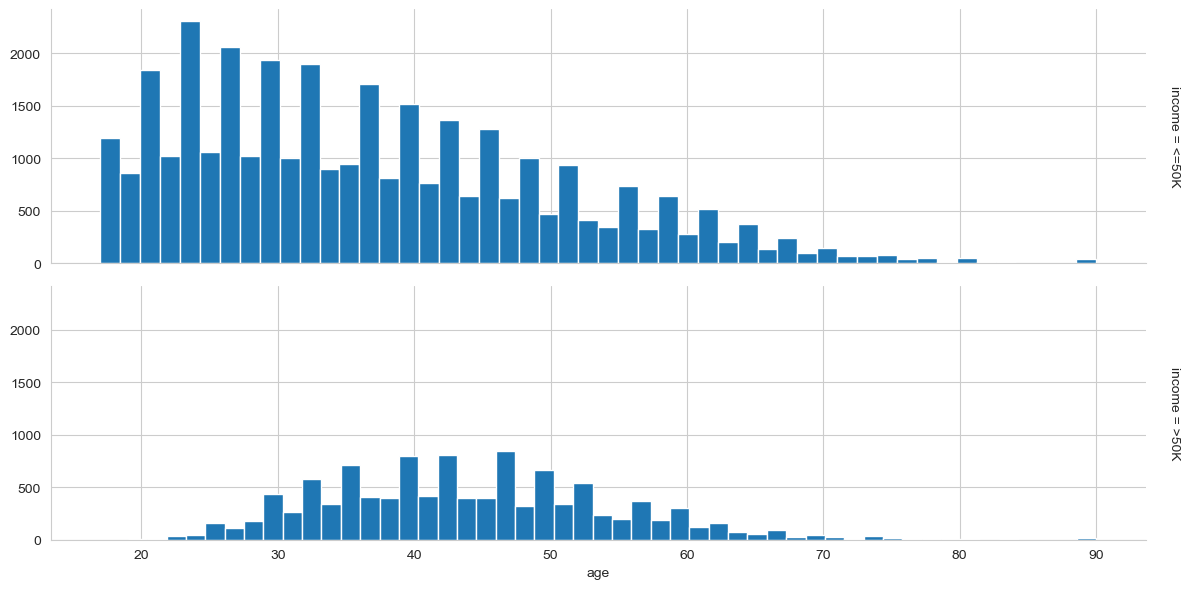

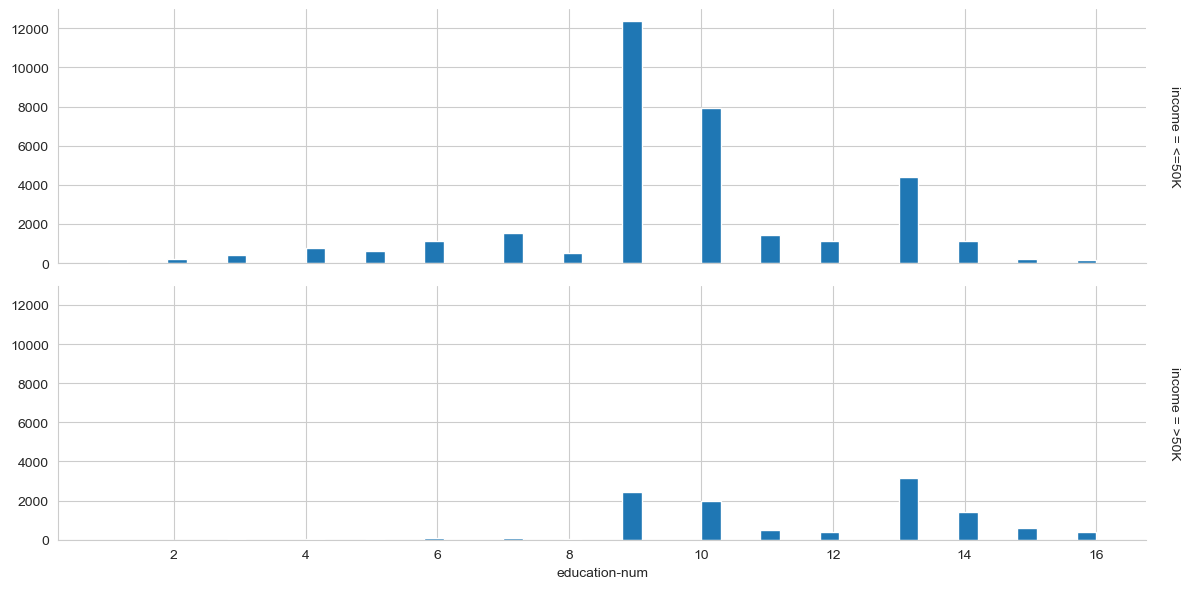

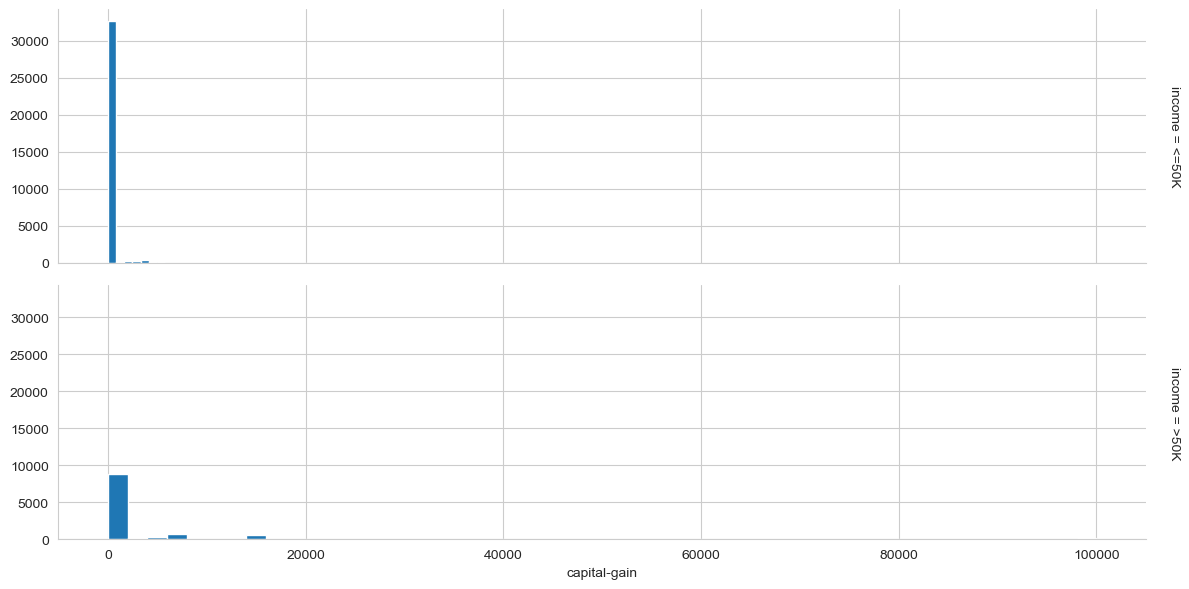

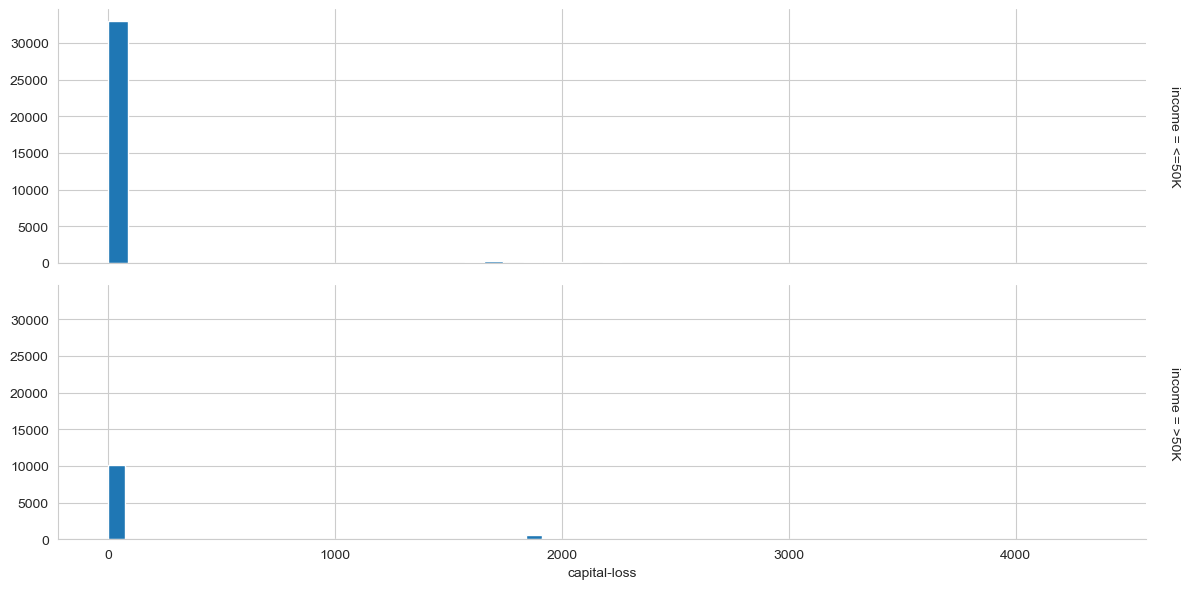

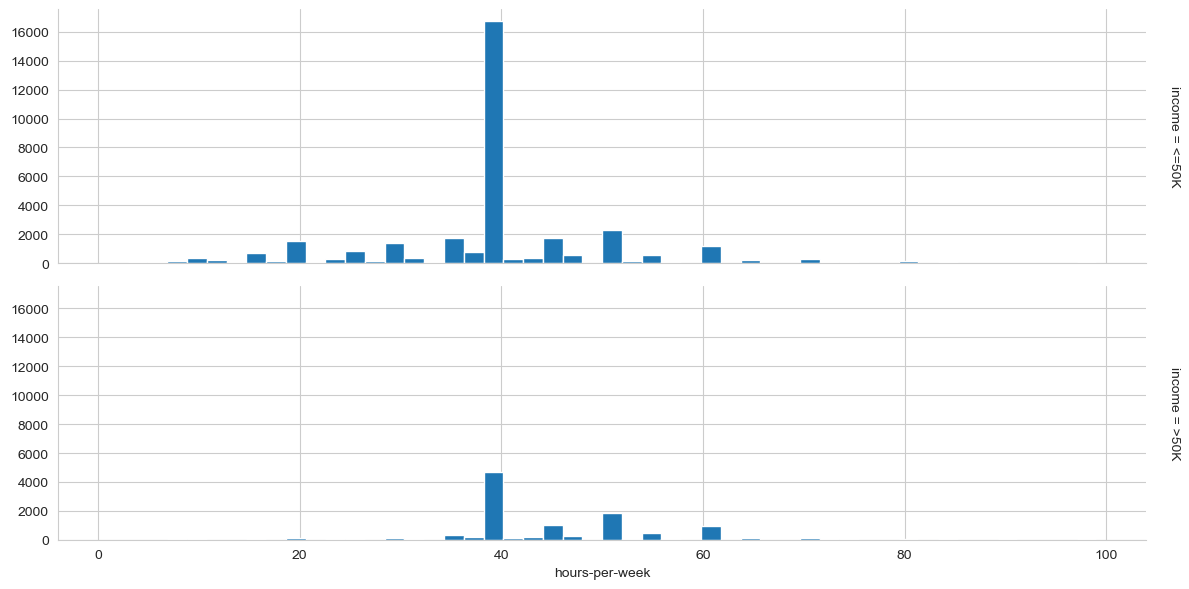

In [16]:
# Distribution of numerical features
for col in numerical_cols:
    g = sns.FacetGrid(df, row='income', margin_titles=True, aspect=4, height=3)
    g.map(plt.hist, col, bins=50) 
    plt.show()

In [17]:
# Check missing
print(f"Number of missing values: {df.isna().sum().sum()}")
print(f"Percentage of missing values:\n{df.isnull().mean() *100}")

Number of missing values: 0
Percentage of missing values:
age                0.0
workclass          0.0
education_level    0.0
education-num      0.0
marital-status     0.0
occupation         0.0
relationship       0.0
race               0.0
sex                0.0
capital-gain       0.0
capital-loss       0.0
hours-per-week     0.0
native-country     0.0
income             0.0
dtype: float64


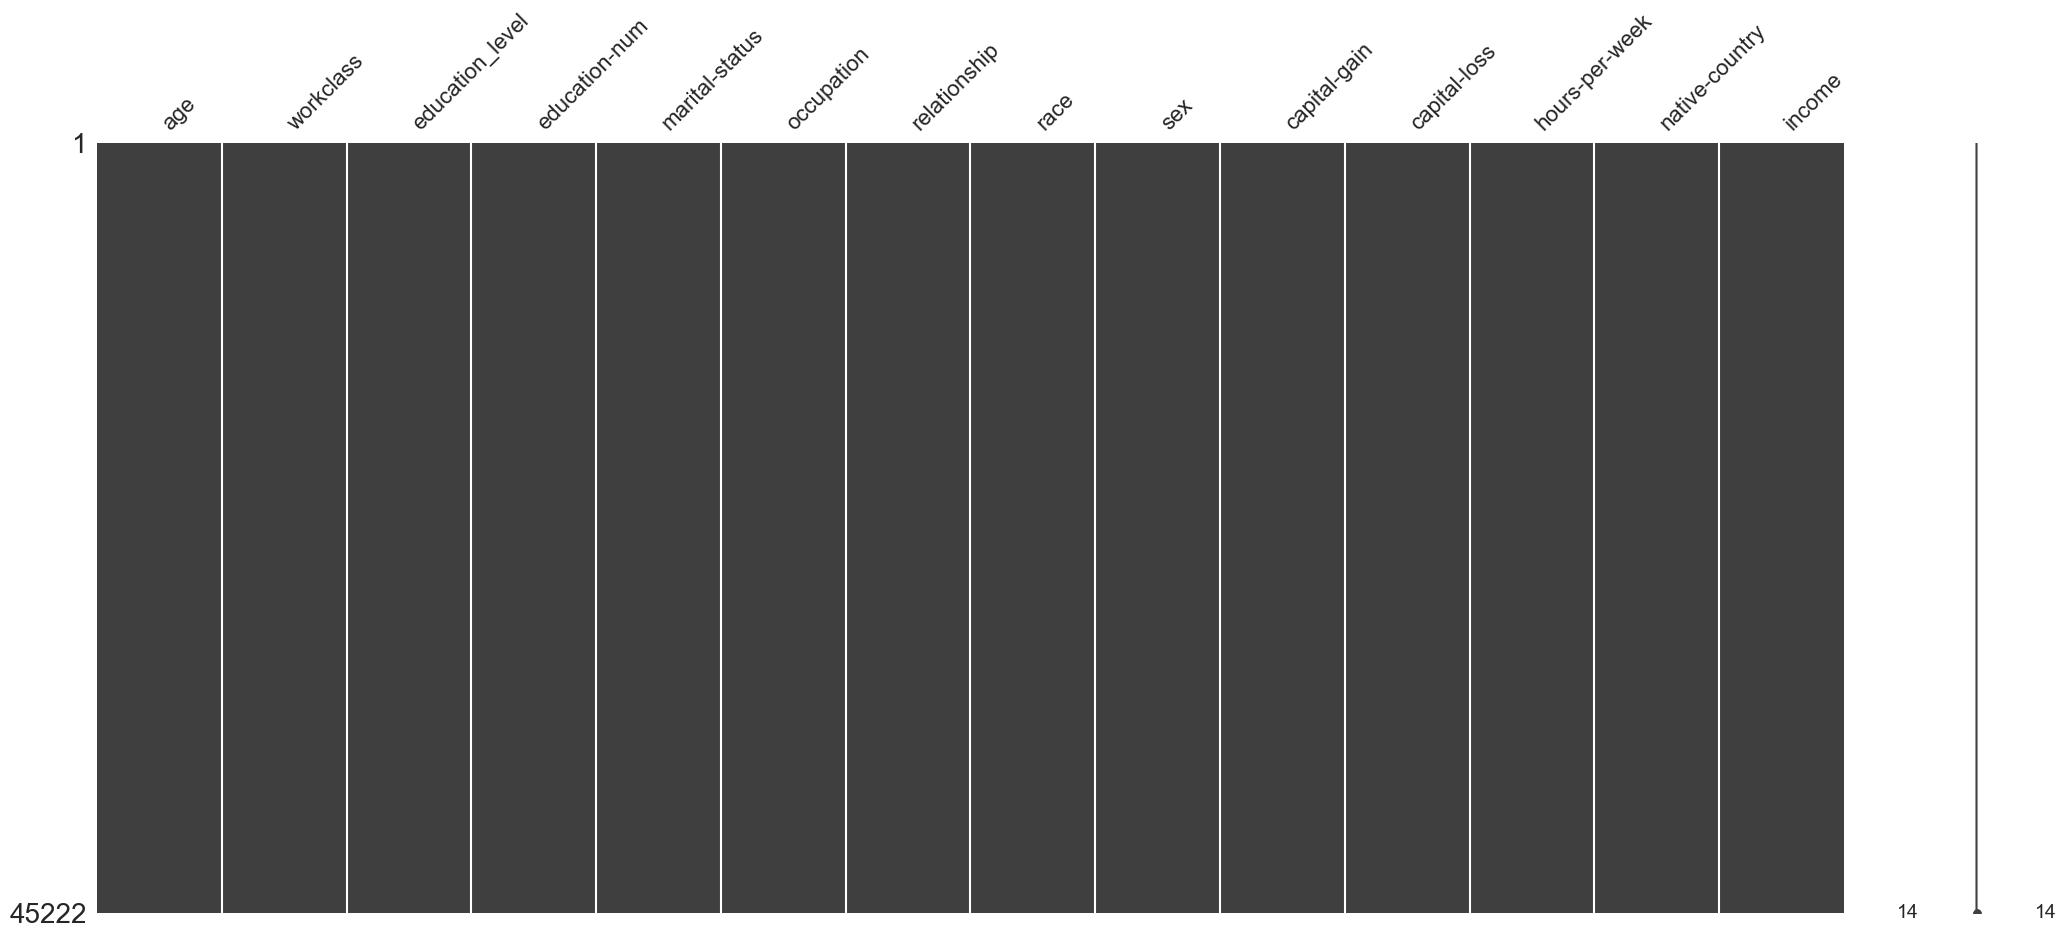

In [18]:
import missingno as msno
msno.matrix(df)
plt.show()

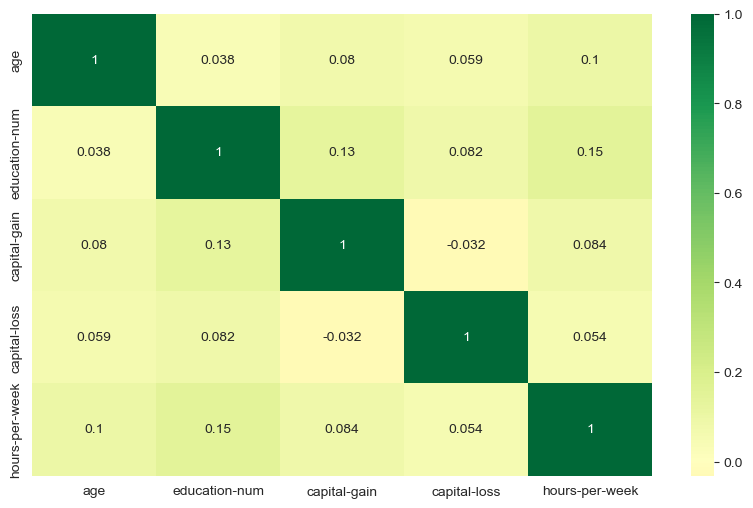

In [19]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', center=0)
plt.show()

**Outlier Detection - Boxplot**

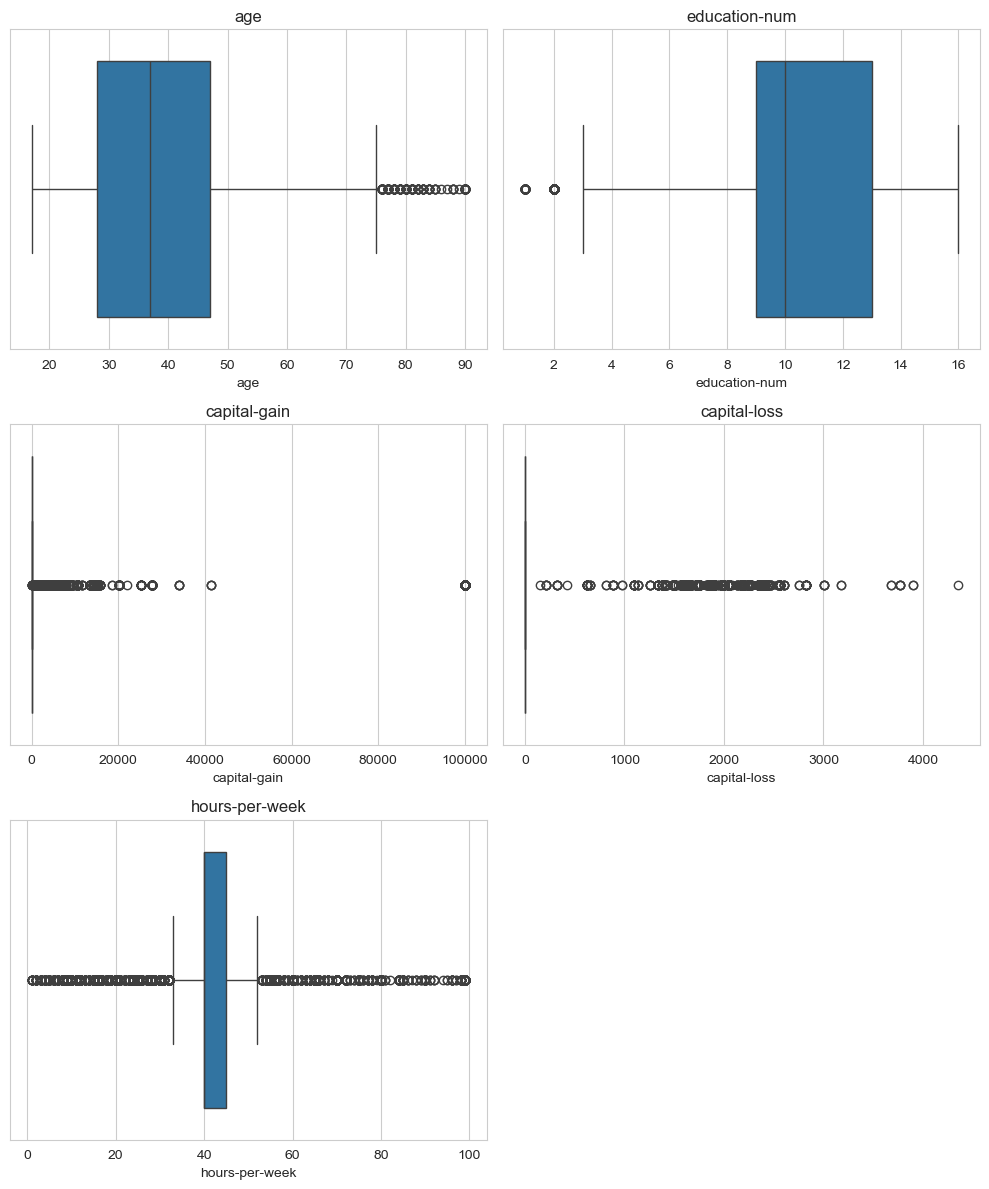

In [20]:
import math

# number of numeric features
n = len(numerical_cols)

# choose grid size dynamically
rows = math.ceil(n/2)  
cols = 2

plt.figure(figsize=(cols*5, rows*4))

for i, feature in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(x=df[feature])
    plt.title(feature)
    plt.tight_layout()

plt.show()

In [21]:
def detect_outliers_iqr(series, lower_percentile=25, upper_percentile=75, factor=1.5):
    Q1 = np.nanpercentile(series, lower_percentile)
    Q3 = np.nanpercentile(series, upper_percentile)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers, len(outliers), lower, upper

In [22]:
for feature in numerical_cols:
    outliers, count, _, _ = detect_outliers_iqr(df[feature])
    print(f'{feature} >> Outliers detected: {count}')

age >> Outliers detected: 269
education-num >> Outliers detected: 294
capital-gain >> Outliers detected: 3790
capital-loss >> Outliers detected: 2140
hours-per-week >> Outliers detected: 11899


- Preprocessing Plan:
  1. Applying log transformation on capital-gain-log & capital-loss-log.
  2. Applying capping on hours-per-week.
  3. Categorical Features encoding.
  4. Handle outliers in hours-per-week.

# Preprocessing & Feature Engineering

In [23]:
# Handle outliers

lower_cap = df['hours-per-week'].quantile(0.01)
upper_cap = df['hours-per-week'].quantile(0.99)
df['hours-per-week'] = df['hours-per-week'].clip(lower_cap, upper_cap)

In [24]:
# Apply log transformation
log_features = ['capital-gain', 'capital-loss']
log_transformer = FunctionTransformer(np.log1p)
df[log_features] = log_transformer.fit_transform(df[log_features])

In [25]:
df.head()

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,7.684784,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0.0,40.0,Cuba,<=50K


In [26]:
# Workclass grouping

df['workclass'] = df['workclass'].replace({
    'Federal-gov':'Gov', 'State-gov':'Gov', 'Local-gov':'Gov',
    'Self-emp-inc':'Self-emp', 'Self-emp-not-inc':'Self-emp',
    'Without-pay':'Other'
})

# Education ordinal encoding 
education_map = {'Preschool':1,'1st-4th':1,'5th-6th':1,'7th-8th':1, 
                 '9th':1,'10th':1,'11th':1,'12th':1,'HS-grad':1,

                 'Some-college':2,'Assoc-acdm':2,'Assoc-voc':2,'Prof-school':2,

                 'Bachelors':3,'Masters':3,'Doctorate':3
}

df['education_level'] = df['education_level'].str.strip()
df['education_level_mapped'] = df['education_level'].map(education_map)

# Occupation ordinal encoding
occupation_map = {'Adm-clerical':1,'Machine-op-inspct':1,'Farming-fishing':1,
                  'Handlers-cleaners':1,'Other-service':1,'Priv-house-serv':1,

                  'Tech-support':2,'Sales':2,'Craft-repair':2,'Transport-moving':2,

                  'Exec-managerial':3,'Prof-specialty':3,'Protective-serv':3, 'Armed-Forces':3
}
df['occupation'] = df['occupation'].str.strip()
df['occupation_level_mapped'] = df['occupation'].map(occupation_map)

# Sex binary encoding
df['sex'] = df['sex'].str.strip().map({'Female':0, 'Male':1})

# New Feature: is_married
df['is_married'] = df['marital-status'].apply(lambda x: 1 if x=='Married-civ-spouse' else 0)

# Native-country grouping (US vs Other)
df['is_US'] = df['native-country'].apply(lambda x: 1 if x == 'United-States' else 0)

# One-hot encoding 
df = pd.get_dummies(df, columns=['workclass','relationship','race'], drop_first=True, dtype=int)

# Target Encoding
df['income'] = df['income'].map({'<=50K':0, '>50K':1})

# Drop unused columns
df.drop(columns=['education_level', 'occupation', 'marital-status', 'native-country'], inplace=True)

In [27]:
# Becaause the majority of people has capital-gain = 0, capital-loss = 0 so i made this feature 'has_capital'
df['has_capital'] = ((df['capital-gain'] > 0) | (df['capital-loss'] > 0)).astype(int)

# How many hours hours vs age
df['work_intensity'] = df['hours-per-week'] / df['age']

# High level education and occupation level Combination
df['edu_occ'] = df['education_level_mapped'] * df['occupation_level_mapped']

# Grouping the 'age' feature
df['age_group'] = pd.cut(df['age'], bins=[0,25,35,50,65,np.inf], labels=[1,2,3,4,5]).astype(int)

In [28]:
df.isna().sum()

age                             0
education-num                   0
sex                             0
capital-gain                    0
capital-loss                    0
hours-per-week                  0
income                          0
education_level_mapped          0
occupation_level_mapped         0
is_married                      0
is_US                           0
workclass_ Local-gov            0
workclass_ Private              0
workclass_ Self-emp-inc         0
workclass_ Self-emp-not-inc     0
workclass_ State-gov            0
workclass_ Without-pay          0
relationship_ Not-in-family     0
relationship_ Other-relative    0
relationship_ Own-child         0
relationship_ Unmarried         0
relationship_ Wife              0
race_ Asian-Pac-Islander        0
race_ Black                     0
race_ Other                     0
race_ White                     0
has_capital                     0
work_intensity                  0
edu_occ                         0
age_group     

In [29]:
df.head(10)

,age,education-num,sex,capital-gain,capital-loss,hours-per-week,income,education_level_mapped,occupation_level_mapped,is_married,...,relationship_ Unmarried,relationship_ Wife,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,has_capital,work_intensity,edu_occ,age_group
0,39,13.0,1,7.684784,0.0,40.0,0,3,1,0,...,0,0,0,0,0,1,1,1.025641,3,3
1,50,13.0,1,0.000000,0.0,13.0,0,3,3,0,...,0,0,0,0,0,1,0,0.260000,9,3
2,38,9.0,1,0.000000,0.0,40.0,0,1,1,0,...,0,0,0,0,0,1,0,1.052632,1,3
3,53,7.0,1,0.000000,0.0,40.0,0,1,1,0,...,0,0,0,1,0,0,0,0.754717,1,4
4,28,13.0,0,0.000000,0.0,40.0,0,3,3,0,...,0,1,0,1,0,0,0,1.428571,9,2
5,37,14.0,0,0.000000,0.0,40.0,0,3,3,0,...,0,1,0,0,0,1,0,1.081081,9,3
6,49,5.0,0,0.000000,0.0,16.0,0,1,1,0,...,0,0,0,1,0,0,0,0.326531,1,3
7,52,9.0,1,0.000000,0.0,45.0,1,1,3,0,...,0,0,0,0,0,1,0,0.865385,3,4
8,31,14.0,0,9.552866,0.0,50.0,1,3,3,0,...,0,0,0,0,0,1,1,1.612903,9,2
9,42,13.0,1,8.552367,0.0,40.0,1,3,3,0,...,0,0,0,0,0,1,1,0.952381,9,3


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           45222 non-null  int64  
 1   education-num                 45222 non-null  float64
 2   sex                           45222 non-null  int64  
 3   capital-gain                  45222 non-null  float64
 4   capital-loss                  45222 non-null  float64
 5   hours-per-week                45222 non-null  float64
 6   income                        45222 non-null  int64  
 7   education_level_mapped        45222 non-null  int64  
 8   occupation_level_mapped       45222 non-null  int64  
 9   is_married                    45222 non-null  int64  
 10  is_US                         45222 non-null  int64  
 11  workclass_ Local-gov          45222 non-null  int32  
 12  workclass_ Private            45222 non-null  int32  
 13  w

In [31]:
# Now Splitting Data into train and test sets

X = df.drop(labels=['income'],axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [32]:
print("X Train Dimension: ", X_train.shape)
print("X Test Dimension: ", X_test.shape)
print("Y Train Dimension: ", y_train.shape)
print("Y Test  Dimension: ", y_test.shape)

X Train Dimension:  (33916, 29)
X Test Dimension:  (11306, 29)
Y Train Dimension:  (33916,)
Y Test  Dimension:  (11306,)


In [33]:
# Feature Scaling using standard scaler
numeric_features = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'work_intensity']

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [35]:
X_train.head()

,age,education-num,sex,capital-gain,capital-loss,hours-per-week,education_level_mapped,occupation_level_mapped,is_married,is_US,...,relationship_ Unmarried,relationship_ Wife,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,has_capital,work_intensity,edu_occ,age_group
32838,0.487052,-1.217192,0,-0.300423,-0.224927,-0.512472,1,2,0,0,...,0,0,0,1,0,0,0,-0.846565,2,3
10770,2.304800,-0.436941,1,-0.300423,-0.224927,-1.461513,1,2,0,0,...,0,0,0,0,0,1,0,-1.774465,2,5
2710,-0.346082,1.123560,1,-0.300423,-0.224927,-0.943854,3,3,0,0,...,0,0,0,1,0,0,0,-0.620876,9,2
33887,-0.043124,-0.046816,1,-0.300423,-0.224927,1.213058,2,3,0,0,...,0,0,0,0,0,1,0,0.598512,6,3
28109,-0.800519,-0.436941,1,-0.300423,-0.224927,-0.081090,1,3,0,0,...,0,0,0,0,0,1,0,0.557945,3,2


# Naive Predictor Performance

In [45]:
TP = np.sum(y)
FP = len(y) -TP
FN = 0

accuracy = TP/len(y)

precision = TP/(TP+FP)
recall = TP/(TP+FN)

beta = 0.5
fscore = (1+beta**2) * (precision * recall) / ((beta**2 * precision)+recall)

print(f"Naive Predictor: [Accuracy score: {accuracy:.4f}, F-score: {fscore:.4f}]")

Naive Predictor: [Accuracy score: 0.2478, F-score: 0.2917]


# Model Selection - Why These Three?

### 1. Logistic Regression

**Pros:** Simple, highly interpretable, fast to train, low cost and works well with scaled features

**Cons:** May miss non-linear interaction

**Why chosen:** Establishes a strong linear baseline; fast to tune and easy to explain 


---
### 2. Random Forest

**Pros:** Handles non-linearity, low variance via bagging, provides `feature_importances_`

**Cons:** Less interpretable than LR, memory-intensive on large datasets, slower to train than single trees

**Why chosen:** The bagging approach reduces overfitting compared to single decision trees 


---
### 3. AdaBoost

**Pros:** Achieves high accuracy with weak learners, less prone to overfitting than a single tree, provides `feature_importances_`

**Cons:** Sensitive to noisy data and outliers (unlike Random Forest), slower than LR

**Why chosen:** AdaBoost's adaptive weighting naturally prioritizes correctly identifying the minority '>50K' class


---
### 4. XGBoost

**Pros:** High predictive accuracy, built-in regularization to reduce overfitting, efficient implementation of gradient boosting, and provides `feature_importances_`

**Cons:** More complex to tune, longer training time than simpler models, and less interpretable than linear models

**Why chosen:** Selected because it is a powerful ensemble method that often achieves good performance on structured datasets like the Census income data.

# Training and Prediction Pipeline

In [46]:
def train_predict(learner , X_tr , y_tr , X_te , y_te):
    t0= time.time()
    learner.fit(X_tr,y_tr)
    train_time = time.time() - t0

    t0= time.time()
    pred = learner.predict(X_te)
    pred_time = time.time() - t0

    acc = accuracy_score(y_te,pred)
    fb = fbeta_score(y_te,pred,beta=0.5)
    
    print(f"{learner.__class__.__name__} trained on {len(X_tr)} samples.")
    
    return acc , fb , train_time , pred_time

In [47]:
samples = [int(len(X_train) * s) for s in [0.01, 0.10, 1.0]] # 1 , 10 , 100 % 
models = { 
    'Logistic Regression': LogisticRegression(max_iter=1000, solver='liblinear', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42)
}


results = {}

for name , clf in models.items():
    results[name] = []
    for s in samples:
        a , f , tt , pt = train_predict(
            clf.__class__(**clf.get_params()),
            X_train.iloc[:s],y_train.iloc[:s],
            X_test,y_test
        )

        results[name].append({'size': s, 'accuracy': a, 'fscore': f,'train_time': tt, 'pred_time': pt})
                                

LogisticRegression trained on 339 samples.
LogisticRegression trained on 3391 samples.
LogisticRegression trained on 33916 samples.
RandomForestClassifier trained on 339 samples.
RandomForestClassifier trained on 3391 samples.
RandomForestClassifier trained on 33916 samples.
AdaBoostClassifier trained on 339 samples.
AdaBoostClassifier trained on 3391 samples.
AdaBoostClassifier trained on 33916 samples.
XGBClassifier trained on 339 samples.
XGBClassifier trained on 3391 samples.
XGBClassifier trained on 33916 samples.


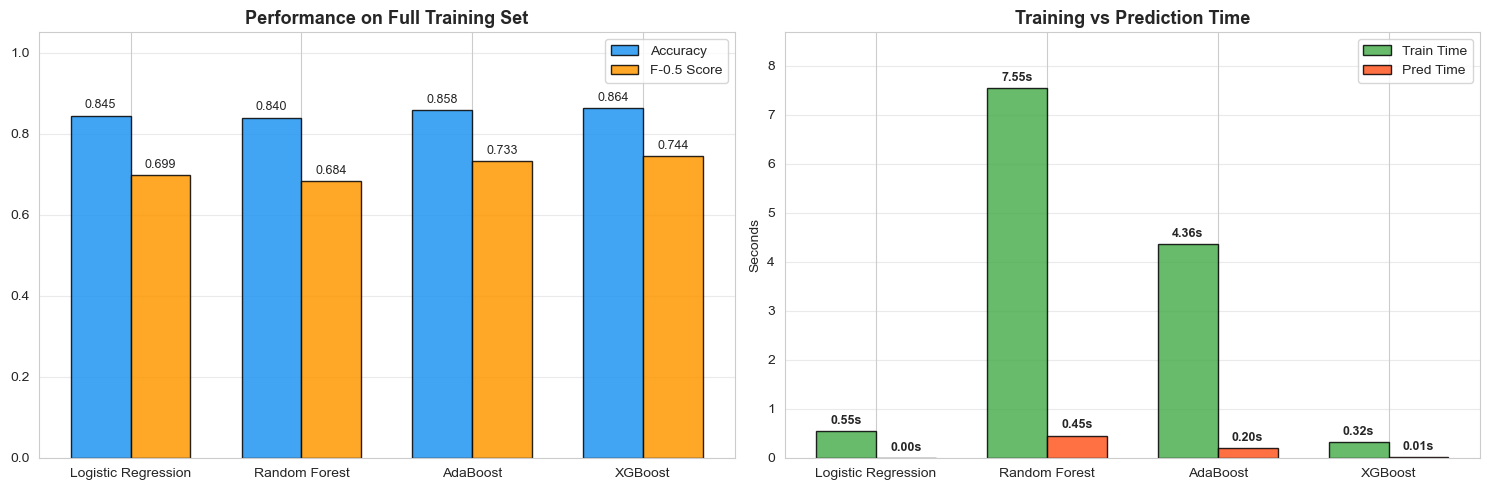

In [48]:
full_results = {name: res[-1] for name, res in results.items()}
names = list(full_results.keys())
accs  = [full_results[n]['accuracy'] for n in names]
fs    = [full_results[n]['fscore']   for n in names]
train_times = [full_results[n]['train_time'] for n in names]
pred_times  = [full_results[n]['pred_time']  for n in names]

x = np.arange(len(names))
w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy & F-score
bars1 = axes[0].bar(x - w/2, accs, w, label='Accuracy',    color='#2196F3', alpha=0.85, edgecolor='black')
bars2 = axes[0].bar(x + w/2, fs,   w, label='F-0.5 Score', color='#FF9800', alpha=0.85, edgecolor='black')

axes[0].set_xticks(x)
axes[0].set_xticklabels(names)

axes[0].set_title('Performance on Full Training Set', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)
axes[0].set_ylim(0, 1.05)
axes[0].bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
axes[0].bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)

# Training & Prediction time
bars3 = axes[1].bar(x - w/2, train_times, w, label='Train Time',    color='#4CAF50', alpha=0.85, edgecolor='black')
bars4 = axes[1].bar(x + w/2, pred_times,   w, label='Pred Time', color='#FF5722', alpha=0.85, edgecolor='black')

axes[1].set_xticks(x)
axes[1].set_xticklabels(names)
axes[1].set_ylim(0, max(max(train_times), max(pred_times)) * 1.15)
axes[1].set_title('Training vs Prediction Time', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Seconds')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.4)

max_time = max(max(train_times), max(pred_times))
offset = max_time * 0.02

axes[1].bar_label(bars3, fmt='%.2fs', padding=3, fontsize=9, fontweight='bold')
axes[1].bar_label(bars4, fmt='%.2fs', padding=3, fontsize=9, fontweight='bold')
    
plt.tight_layout()
plt.show()

# Best Model - Why ?

**XGBoost is the best model.**

Why?

1. **Performance:** XGBoost achieves the highest F-0.5 score (74.4%) and accuracy (86.4%). F-0.5 is our key metric since CharityML needs `precision` — we want the letters we send to actually reach donors, minimizing waste on false positives.

2. **Computational efficiency:** Training time (0.22s) and prediction time (0.01s) are extremely fast — comparable to Logistic Regression and much faster than Random Forest.

3. **Adaptive and regularized nature:** XGBoost uses gradient boosting with regularization, which effectively captures complex feature interactions while preventing overfitting — ideal for imbalanced datasets like this one.

4. **Data characteristics:** The census dataset has non-linear relationships and interactions among features (e.g., education × age × occupation × hours-per-week). XGBoost captures these complex patterns efficiently, outperforming simpler ensemble models like AdaBoost and Random Forest.

#  XGBoost in Layman's Terms

Imagine you are building a team of analysts. Instead of each one working independently on the problem, every new member of the team works on the errors made by the entire team so far. 

The first member of the team makes a prediction on the people making more than $50K. Then you analyze the errors. Instead of just pointing out the errors, you calculate the actual error. 

The second member of the team does not start from scratch. Instead, they try to correct the errors made by the first member. The third member of the team works on the errors made by the first two members. 

The model improves gradually. Instead of making a **separate** vote, each member adds a small correction to the overall model. 

To stop the model from becoming too complex, there are rules added to the model to stop overfitting.

So it’s a team of simple models, each learning from the previous one’s errors, but it adds smart math to handle how big the errors are, prevent overfitting, and combine the team efficiently.

In simple terms, the model improves by adding many small correction models.

The “X” in XGBoost can be thought of as `Extreme` — because it’s extremely good at squeezing every bit of performance out of those simple models.

# Model Tuning with Grid Search

In [49]:
param = {
    'n_estimators':  [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5],
    'subsample': [0.8, 1]
}

print("Running Grid Search on XGBoost...")
t0 = time.time()
xgboost_clf = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
g_search = GridSearchCV(xgboost_clf, param, cv=3, scoring='f1', n_jobs= -1)
g_search.fit(X_train, y_train)
end = time.time() - t0

print(f"\nGrid Search completed in {end:.1f}s")
print(f"Best parameters : {g_search.best_params_}")
print(f"Best CV F1 score: {g_search.best_score_:.4f}")

Running Grid Search on XGBoost...

Grid Search completed in 10.7s
Best parameters : {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1}
Best CV F1 score: 0.7046


# Model Evaluation

In [52]:
# Unoptimized XGBoost
xgb_unopt = XGBClassifier(random_state=42)
xgb_unopt.fit(X_train, y_train)
pred_unopt = xgb_unopt.predict(X_test)
acc_unopt = accuracy_score(y_test, pred_unopt)
f_unopt   = fbeta_score(y_test, pred_unopt, beta=0.5)

# Optimized XGBoost
best_model = g_search.best_estimator_
pred_opt = best_model.predict(X_test)
acc_opt = accuracy_score(y_test, pred_opt)
f_opt   = fbeta_score(y_test, pred_opt, beta=0.5)

res_data = {
    "Model": ["Naive Predictor", "XGBoost (Unoptimized)", "XGBoost (Optimized)"],
    "Accuracy": [accuracy, acc_unopt, acc_opt],
    "F-0.5 Score": [fscore, f_unopt, f_opt]
}

res_df = pd.DataFrame(res_data)
res_df

,Model,Accuracy,F-0.5 Score
0,Naive Predictor,0.247844,0.291729
1,XGBoost (Unoptimized),0.863082,0.741223
2,XGBoost (Optimized),0.864320,0.744645


In [83]:
# Visualiztion Needed

In [84]:
# Classifiaction Report also 

## Feature Relevance Observation
**Five features that are likely to be the most relevant for prediction for income**

`Age` – Older people generally have more work experience and career progression, which the chances of earning more than 50K are high for them.

`Education Level/Education-num` – Higher education levels often lead to better job opportunities and higher salaries.

`Hours-per-week` – People who work more hours are more likely to earn higher incomes.

`Occupation` – People who have an occupation such as an executive or a manager tend to have a high salary.

`Capital Gain` – Individuals with significant capital gains typically have investments or assets, which strongly correlates with higher income.

- These features were chosen because they directly relate to work experience, job quality, and financial activity, which are strong indicators of income level.

## Extracting Feature Importances

In [57]:
# Get feature importances
importances = best_model.feature_importances_

fimportances = pd.DataFrame({"Feature": X_train.columns, "Importance": importances})
fimportances = fimportances.sort_values(by="Importance", ascending=False)

top10 = fimportances.head(10)
top10

,Feature,Importance
27,edu_occ,0.154431
18,relationship_ Own-child,0.145316
2,sex,0.110387
16,relationship_ Not-in-family,0.105923
19,relationship_ Unmarried,0.076755
7,occupation_level_mapped,0.067186
20,relationship_ Wife,0.054172
3,capital-gain,0.053315
0,age,0.039396
25,has_capital,0.035258


<Figure size 1000x600 with 0 Axes>

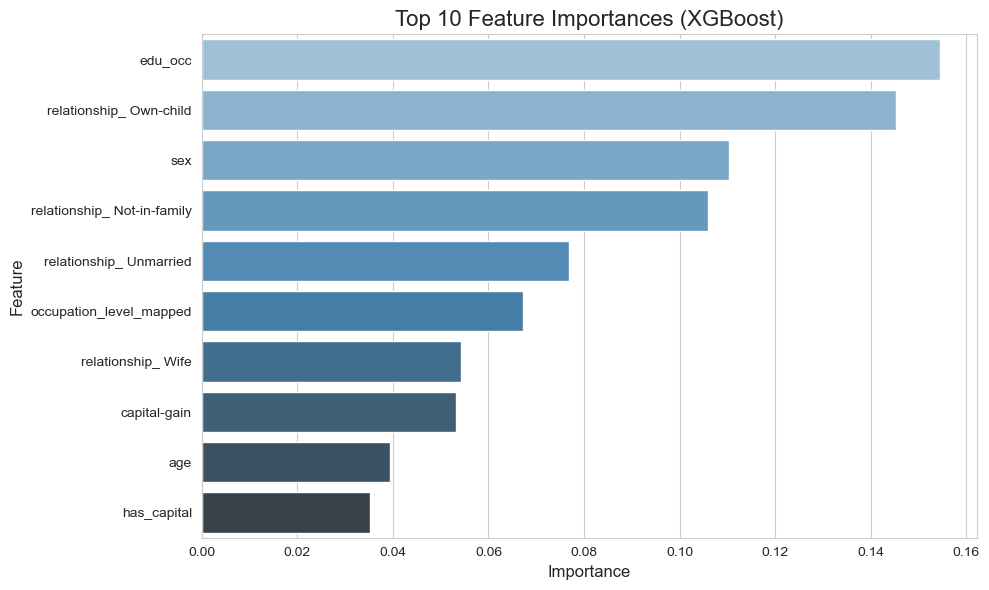

In [58]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance",  y="Feature", data=top10, palette="Blues_d")

plt.title("Top 10 Feature Importances (XGBoost)", fontsize=16)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()

## Effects of Feature Selection

In [68]:
top5 = fimportances.head(5)["Feature"]
X_train_top5 = X_train[top5]
X_test_top5 = X_test[top5]

xgb_top5 = best_model
xgb_top5.fit(X_train_top5, y_train)
pred_top5 = xgb_top5.predict(X_test_top5)

# Evaluation
acc_top5 = accuracy_score(y_test, pred_top5)
f_top5 = fbeta_score(y_test, pred_top5, beta=0.5)

print("Accuracy with all features:", acc_opt)
print("Accuracy with top 5 features:", acc_top5)
print(10*'*')
print("F0.5 score with top all features:", f_opt)
print("F0.5 score with top 5 features:", f_top5)

Accuracy with all features: 0.8643198301786662
Accuracy with top 5 features: 0.8154077480983548
**********
F0.5 score with top all features: 0.7446449654241862
F0.5 score with top 5 features: 0.6286170425064858


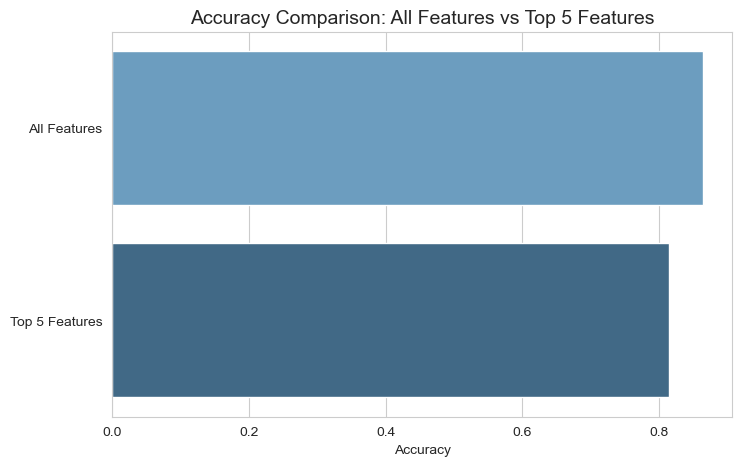

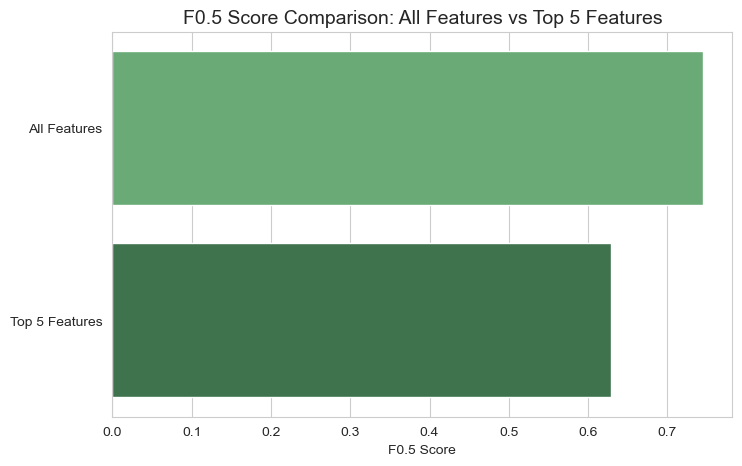

In [69]:
comp = pd.DataFrame({
    "Feature Set": ["All Features", "Top 5 Features"],
    "Accuracy": [acc_opt, acc_top5],
    "F0.5 Score": [f_opt, f_top5]
})

# Accuracy Comparison
plt.figure(figsize=(8,5))
sns.barplot(x="Accuracy", y="Feature Set", data=comp, palette="Blues_d")
plt.title("Accuracy Comparison: All Features vs Top 5 Features", fontsize=14)
plt.xlabel("Accuracy")
plt.ylabel("")
plt.show()
# F0.5 Score Comparison
plt.figure(figsize=(8,5))
sns.barplot(x="F0.5 Score", y="Feature Set", data=comp, palette="Greens_d")
plt.title("F0.5 Score Comparison: All Features vs Top 5 Features", fontsize=14)
plt.xlabel("F0.5 Score")
plt.ylabel("")
plt.show()

**Comparison Between XGBoost Optimized (all features) & XGBoost (Top 5 features)**
---
- When the model was trained with the top five features, the results were not as good as the optimized model with all the features. The accuracy decreased from 0.864 to 0.815, while the F0.5 score decreased from 0.744 to 0.629. This shows that, although the top five features are the ones with the majority of the prediction power, the rest of the features are contributing some useful information, which makes the model better at identifying high-income individuals.